# NEPR — Network Entanglement Pair Reservation

Este notebook demonstra o protocolo **NEPR** na camada de aplicação do QuantumNet.

- Topologia: grade **3×4** (12 nós)
- Dois nós sorteados aleatoriamente como Alice e Bob
- **10 requisições** NEPR entre os mesmos nós
- Log de execução gravado em `nepr.log`
- Métricas de eventos gravadas em `nepr_metrics.csv`

## 1. Imports

In [1]:
import sys
sys.path.append('../') 

import pandas as pd
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from quantumnet.topology import Network
from quantumnet.runtime import Clock
from quantumnet.config import SimulationConfig
from quantumnet.utils import MetricsCollector, Logger

## 2. Parâmetros da simulação

In [2]:
ROWS         = 3          # linhas da grade
COLS         = 4          # colunas da grade  →  12 nós no total
NUM_REQUESTS = 10         # número de requisições NEPR
NUM_PAIRS    = 5          # pares EPR por requisição
SEED         = 1         # semente para reprodutibilidade

LOG_FILE     = 'nepr.log'
METRICS_CSV  = 'nepr_metrics.csv'

print(f"Topologia : Grade {ROWS}×{COLS} = {ROWS * COLS} nós")
print(f"Requisições : {NUM_REQUESTS} × {NUM_PAIRS} pares EPR")
print(f"Log        → {LOG_FILE}")
print(f"Métricas   → {METRICS_CSV}")

Topologia : Grade 3×4 = 12 nós
Requisições : 10 × 5 pares EPR
Log        → nepr.log
Métricas   → nepr_metrics.csv


## 3. Ativar logger externo

In [3]:
logger = Logger.get_instance()
logger.activate(level='DEBUG', filename=LOG_FILE, console=False, file_log=True)

print(f"Logger ativado — saída em '{LOG_FILE}'")

Logger ativado — saída em 'nepr.log'


## 4. Configuração da rede

In [4]:
config = SimulationConfig()
config.defaults.qubits_per_host      = 10   # qubits iniciais por nó
config.defaults.qubit_regen_interval = 10   # ticks entre ciclos de regeneração
config.defaults.qubit_regen_amount   = 5    # qubits adicionados por nó por ciclo

clock = Clock()
net   = Network(clock=clock, config=config)

print("Rede instanciada com Clock e SimulationConfig.")
print(f"Qubits iniciais por nó     : {config.defaults.qubits_per_host}")
print(f"Intervalo de regeneração   : {config.defaults.qubit_regen_interval} ticks")
print(f"Qubits por ciclo (por nó)  : {config.defaults.qubit_regen_amount}")

Rede instanciada com Clock e SimulationConfig.
Qubits iniciais por nó     : 10
Intervalo de regeneração   : 10 ticks
Qubits por ciclo (por nó)  : 5


## 5. Definir topologia e sortear nós

In [5]:
random.seed(SEED)
all_nodes = list(range(ROWS * COLS))
alice_id, bob_id = random.sample(all_nodes, 2)

print(f"Nós disponíveis : {all_nodes}")
print(f"Alice (origem)  : nó {alice_id}")
print(f"Bob   (destino) : nó {bob_id}")
print()
print("Layout da grade 3×4:")
for r in range(ROWS):
    row_nodes = [r * COLS + c for c in range(COLS)]
    markers   = [
        f"[A={n}]" if n == alice_id else
        f"[B={n}]" if n == bob_id  else
        f"  {n:2}  "
        for n in row_nodes
    ]
    print("  ".join(markers))

Nós disponíveis : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Alice (origem)  : nó 2
Bob   (destino) : nó 9

Layout da grade 3×4:
   0       1    [A=2]     3  
   4       5       6       7  
   8    [B=9]    10      11  


## 6. Executar 10 requisições NEPR

In [6]:
results = []

def make_callback(req_id):
    """Retorna um callback que captura o resultado e dispara a próxima requisição."""
    def on_complete(success, measurements):
        meas  = measurements or []
        avg_f = round(sum(meas) / len(meas), 6) if meas else None
        results.append({
            'requisição'       : req_id + 1,
            'alice'            : alice_id,
            'bob'              : bob_id,
            'pares_solicitados': NUM_PAIRS,
            'pares_medidos'    : len(meas),
            'sucesso'          : success,
            'fidelidade_média' : avg_f,
            'medições'         : meas,
        })
        # Encadeia a próxima requisição (serialização)
        next_id = req_id + 1
        if next_id < NUM_REQUESTS:
            net.application_layer.nepr_protocol(
                alice_id, bob_id, NUM_PAIRS,
                on_complete=make_callback(next_id)
            )
        else:
            # Última requisição concluída — para a regeneração
            net.physical.stop_qubit_regen()
    return on_complete


with MetricsCollector(clock, METRICS_CSV) as col:
    # A topologia é definida DENTRO do contexto para capturar eventos de setup
    net.set_ready_topology('Grid', ROWS, COLS)

    # Dispara apenas a primeira requisição; as demais são encadeadas via callback
    net.application_layer.nepr_protocol(
        alice_id, bob_id, NUM_PAIRS,
        on_complete=make_callback(0)
    )

    # Executa a simulação — termina quando não há mais eventos pendentes
    clock.run()

print(f"Simulação concluída — {len(results)} callbacks recebidos.")
print(f"Métricas salvas em '{METRICS_CSV}'.")

Simulação concluída — 10 callbacks recebidos.
Métricas salvas em 'nepr_metrics.csv'.


## 7. Resultados das medições

In [7]:
df_results = pd.DataFrame(results)

# Tabela resumida (sem a coluna de lista de medições)
print("=== Resumo das 10 requisições NEPR ===")
display(df_results.drop(columns=['medições']))

# Estatísticas gerais
sucessos   = df_results['sucesso'].sum()
falhas     = NUM_REQUESTS - sucessos
fids_valid = df_results.loc[df_results['sucesso'], 'fidelidade_média'].dropna()

print()
print(f"Sucesso : {sucessos}/{NUM_REQUESTS}")
print(f"Falha   : {falhas}/{NUM_REQUESTS}")
if not fids_valid.empty:
    print(f"Fidelidade média (sucessos) : {fids_valid.mean():.6f}")
    print(f"Fidelidade mínima          : {fids_valid.min():.6f}")
    print(f"Fidelidade máxima          : {fids_valid.max():.6f}")

=== Resumo das 10 requisições NEPR ===


,requisição,alice,bob,pares_solicitados,pares_medidos,sucesso,fidelidade_média
0,1,2,9,5,0,False,NaN
1,2,2,9,5,4,True,0.518904
2,3,2,9,5,4,True,0.401415
3,4,2,9,5,4,True,0.401415
4,5,2,9,5,4,True,0.401415
5,6,2,9,5,4,True,0.401415
6,7,2,9,5,4,True,0.401415
7,8,2,9,5,4,True,0.401415
8,9,2,9,5,4,True,0.401415
9,10,2,9,5,4,True,0.401415



Sucesso : 9/10
Falha   : 1/10
Fidelidade média (sucessos) : 0.414469
Fidelidade mínima          : 0.401415
Fidelidade máxima          : 0.518904


## 8. Medições individuais por requisição

In [8]:
print("=== Fidelidades individuais por requisição ===")
for row in results:
    status = "OK" if row['sucesso'] else "FALHOU"
    meas_str = ", ".join(f"{f:.6f}" for f in row['medições']) if row['medições'] else "—"
    print(f"  Req {row['requisição']:>2} [{status}]  "
          f"Alice={row['alice']} → Bob={row['bob']}  "
          f"fidelidades=[{meas_str}]  "
          f"média={row['fidelidade_média']}")

=== Fidelidades individuais por requisição ===
  Req  1 [FALHOU]  Alice=2 → Bob=9  fidelidades=[—]  média=None
  Req  2 [OK]  Alice=2 → Bob=9  fidelidades=[0.282430, 0.254187, 0.810000, 0.729000]  média=0.518904
  Req  3 [OK]  Alice=2 → Bob=9  fidelidades=[0.109419, 0.313811, 0.282430, 0.900000]  média=0.401415
  Req  4 [OK]  Alice=2 → Bob=9  fidelidades=[0.109419, 0.313811, 0.282430, 0.900000]  média=0.401415
  Req  5 [OK]  Alice=2 → Bob=9  fidelidades=[0.109419, 0.313811, 0.282430, 0.900000]  média=0.401415
  Req  6 [OK]  Alice=2 → Bob=9  fidelidades=[0.109419, 0.313811, 0.282430, 0.900000]  média=0.401415
  Req  7 [OK]  Alice=2 → Bob=9  fidelidades=[0.109419, 0.313811, 0.282430, 0.900000]  média=0.401415
  Req  8 [OK]  Alice=2 → Bob=9  fidelidades=[0.109419, 0.313811, 0.282430, 0.900000]  média=0.401415
  Req  9 [OK]  Alice=2 → Bob=9  fidelidades=[0.109419, 0.313811, 0.282430, 0.900000]  média=0.401415
  Req 10 [OK]  Alice=2 → Bob=9  fidelidades=[0.109419, 0.313811, 0.282430, 0.9000

## 9. Eventos registrados no CSV de métricas

In [9]:
df_metrics = pd.read_csv(METRICS_CSV)

print(f"Total de eventos registrados: {len(df_metrics)}")
print(f"Tipos de eventos: {df_metrics['event_type'].unique().tolist()}")
print()

# Filtrar apenas eventos da camada de aplicação (NEPR)
nepr_mask    = df_metrics['event_type'].isin(['nepr_complete', 'nepr_failed'])
df_nepr_evts = df_metrics[nepr_mask].reset_index(drop=True)

print(f"=== Eventos NEPR ({len(df_nepr_evts)}) ===")
display(df_nepr_evts)

Total de eventos registrados: 4321
Tipos de eventos: ['qubit_created', 'epr_created', 'link_request_attempt', 'echp_success', 'link_request_success', 'echp_low_fidelity', 'qubits_regenerated', 'route_lookup', 'route_found', 'epr_request_failed', 'nepr_failed', 'epr_expired', 'qubit_expired', 'entanglement_swapping_complete', 'epr_request_complete', 'nepr_complete']

=== Eventos NEPR (10) ===


,clock_tick,event_type,source_node,target_node,value,details
0,13,nepr_failed,2.0,9.0,5.0,"{""reason"":""entanglement_failed"",""created"":0}"
1,42,nepr_complete,2.0,9.0,NaN,"{""num_pairs"":4,""measurements"":""[0.282429536481..."
2,71,nepr_complete,2.0,9.0,NaN,"{""num_pairs"":4,""measurements"":""[0.109418989131..."
3,101,nepr_complete,2.0,9.0,NaN,"{""num_pairs"":4,""measurements"":""[0.109418989131..."
4,131,nepr_complete,2.0,9.0,NaN,"{""num_pairs"":4,""measurements"":""[0.109418989131..."
5,161,nepr_complete,2.0,9.0,NaN,"{""num_pairs"":4,""measurements"":""[0.109418989131..."
6,191,nepr_complete,2.0,9.0,NaN,"{""num_pairs"":4,""measurements"":""[0.109418989131..."
7,221,nepr_complete,2.0,9.0,NaN,"{""num_pairs"":4,""measurements"":""[0.109418989131..."
8,251,nepr_complete,2.0,9.0,NaN,"{""num_pairs"":4,""measurements"":""[0.109418989131..."
9,281,nepr_complete,2.0,9.0,NaN,"{""num_pairs"":4,""measurements"":""[0.109418989131..."


## 10. Inspecionar o arquivo de log externo

In [10]:
import os

if os.path.exists(LOG_FILE):
    size_kb = os.path.getsize(LOG_FILE) / 1024
    with open(LOG_FILE, 'r', encoding='utf-8', errors='replace') as f:
        lines = f.readlines()
    print(f"Arquivo '{LOG_FILE}' — {len(lines)} linhas / {size_kb:.1f} KB")
    print()
    print("--- Últimas 30 linhas do log ---")
    print(''.join(lines[-30:]))
else:
    print(f"Arquivo '{LOG_FILE}' não encontrado (o logger pode estar desativado).")

Arquivo 'nepr.log' — 7424952 linhas / 722202.0 KB

--- Últimas 30 linhas do log ---
2026-03-15 23:29:11,361 [DEBUG] Qubit 1769 expired and removed from Host 5 at timeslot 302.
2026-03-15 23:29:11,361 [DEBUG] Qubit 1770 expired and removed from Host 6 at timeslot 302.
2026-03-15 23:29:11,361 [DEBUG] Qubit 1771 expired and removed from Host 6 at timeslot 302.
2026-03-15 23:29:11,361 [DEBUG] Qubit 1772 expired and removed from Host 6 at timeslot 302.
2026-03-15 23:29:11,361 [DEBUG] Qubit 1773 expired and removed from Host 6 at timeslot 302.
2026-03-15 23:29:11,361 [DEBUG] Qubit 1774 expired and removed from Host 6 at timeslot 302.
2026-03-15 23:29:11,361 [DEBUG] Qubit 1775 expired and removed from Host 7 at timeslot 302.
2026-03-15 23:29:11,361 [DEBUG] Qubit 1776 expired and removed from Host 7 at timeslot 302.
2026-03-15 23:29:11,361 [DEBUG] Qubit 1777 expired and removed from Host 7 at timeslot 302.
2026-03-15 23:29:11,361 [DEBUG] Qubit 1778 expired and removed from Host 7 at timeslot 3

## 11. Visualização — Decoerrência e Métricas do Simulador

Os gráficos a seguir são derivados **exclusivamente** dos eventos gravados em `nepr_metrics.csv` durante a execução da simulação.

| Seção | Métrica |
|---|---|
| 11.1 | Fidelidade vs. ordem de criação do par EPR — decoerrência acumulada por espera |
| 11.2 | Contagem de qubits ativos ao longo do tempo |

In [11]:
# ── Configuração de visualização — carrega CSV e variáveis compartilhadas ─────
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Recarrega o CSV (permite rodar esta seção de forma independente)
df_v = pd.read_csv(METRICS_CSV)

# Variáveis de referência reutilizadas em todos os gráficos
nepr_complete_ticks = df_v.loc[df_v['event_type'] == 'nepr_complete', 'clock_tick'].tolist()
nepr_failed_ticks   = df_v.loc[df_v['event_type'] == 'nepr_failed',   'clock_tick'].tolist()
regen_ticks         = df_v.loc[df_v['event_type'] == 'qubits_regenerated', 'clock_tick'].tolist()

print(f"Dados carregados: {len(df_v)} eventos  |  "
      f"ticks 0 – {int(df_v['clock_tick'].max())}")
print(f"NEPR concluídos : {len(nepr_complete_ticks)}  |  "
      f"NEPR falhados : {len(nepr_failed_ticks)}  |  "
      f"Ciclos de regeneração : {len(regen_ticks)}")

Dados carregados: 4321 eventos  |  ticks 0 – 302
NEPR concluídos : 9  |  NEPR falhados : 1  |  Ciclos de regeneração : 28


### 11.1  Decoerrência — Fidelidade vs. Ordem de Criação do Par EPR

Dentro de cada requisição NEPR, os pares são estabelecidos **em sequência**. O **1º par** (criado primeiro) fica esperando enquanto os demais são estabelecidos, acumulando mais decoerência → fidelidade final **menor**. O **último par** é medido logo após ser criado → fidelidade **maior**.

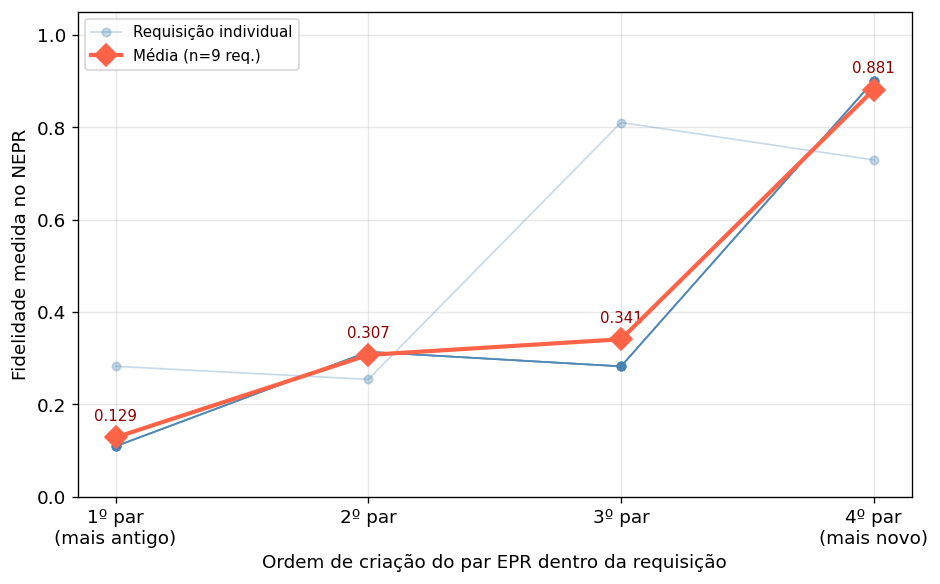

Figura salva em 'nepr_decoherence_age.png'


In [12]:
import ast

# ── Parse nepr_complete measurements do CSV ───────────────────────────────────
df_nc = df_v[df_v['event_type'] == 'nepr_complete'].copy()

def _parse_meas(details_str):
    if not pd.notna(details_str) or not details_str:
        return []
    try:
        d = json.loads(details_str)
        m = d.get('measurements', [])
        return ast.literal_eval(m) if isinstance(m, str) else m
    except Exception:
        return []

df_nc['meas'] = df_nc['details'].apply(_parse_meas)

pair_rows = []
for req_num, (_, row) in enumerate(df_nc.iterrows(), start=1):
    for idx, fid in enumerate(row['meas']):
        pair_rows.append({'requisição': req_num, 'índice_par': idx, 'fidelidade': fid})
df_pairs = pd.DataFrame(pair_rows)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

if not df_pairs.empty:
    n_idx = df_pairs['índice_par'].nunique()
    for i, (_, grp) in enumerate(df_pairs.groupby('requisição')):
        ax.plot(grp['índice_par'], grp['fidelidade'], 'o-',
                alpha=0.30, linewidth=1, markersize=5, color='steelblue',
                label='Requisição individual' if i == 0 else '_nolegend_')

    avg = df_pairs.groupby('índice_par')['fidelidade'].mean()
    ax.plot(avg.index, avg.values, 'D-',
            color='tomato', linewidth=2.5, markersize=9, zorder=10,
            label=f'Média (n={len(df_nc)} req.)')
    for idx, fid in avg.items():
        ax.text(idx, fid + 0.03, f'{fid:.3f}',
                ha='center', va='bottom', fontsize=9, color='darkred')

    labels = (['1º par\n(mais antigo)'] +
              [f'{i+1}º par' for i in range(1, n_idx - 1)] +
              [f'{n_idx}º par\n(mais novo)'])
    ax.set_xticks(range(n_idx))
    ax.set_xticklabels(labels)
    ax.set_xlabel('Ordem de criação do par EPR dentro da requisição')
    ax.set_ylabel('Fidelidade medida no NEPR')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nepr_decoherence_age.png', bbox_inches='tight')
plt.show()
print("Figura salva em 'nepr_decoherence_age.png'")

### 11.2  Ciclo de Vida dos Qubits — População Ativa ao Longo do Tempo

O gráfico rastreia o número total de qubits **ativos** em toda a rede a cada tick, reconstruído a partir dos eventos `qubit_created` e `qubit_expired`.

- **Pico inicial (`t = 0`)**: criação simultânea de todos os qubits (12 nós × 10 = **120 qubits**).  
- **Quedas graduais**: qubits expiram por decoerência (vida útil finita).  
- **Pulsos de subida periódicos**: ciclos de regeneração a cada 10 ticks (+60 qubits por ciclo).

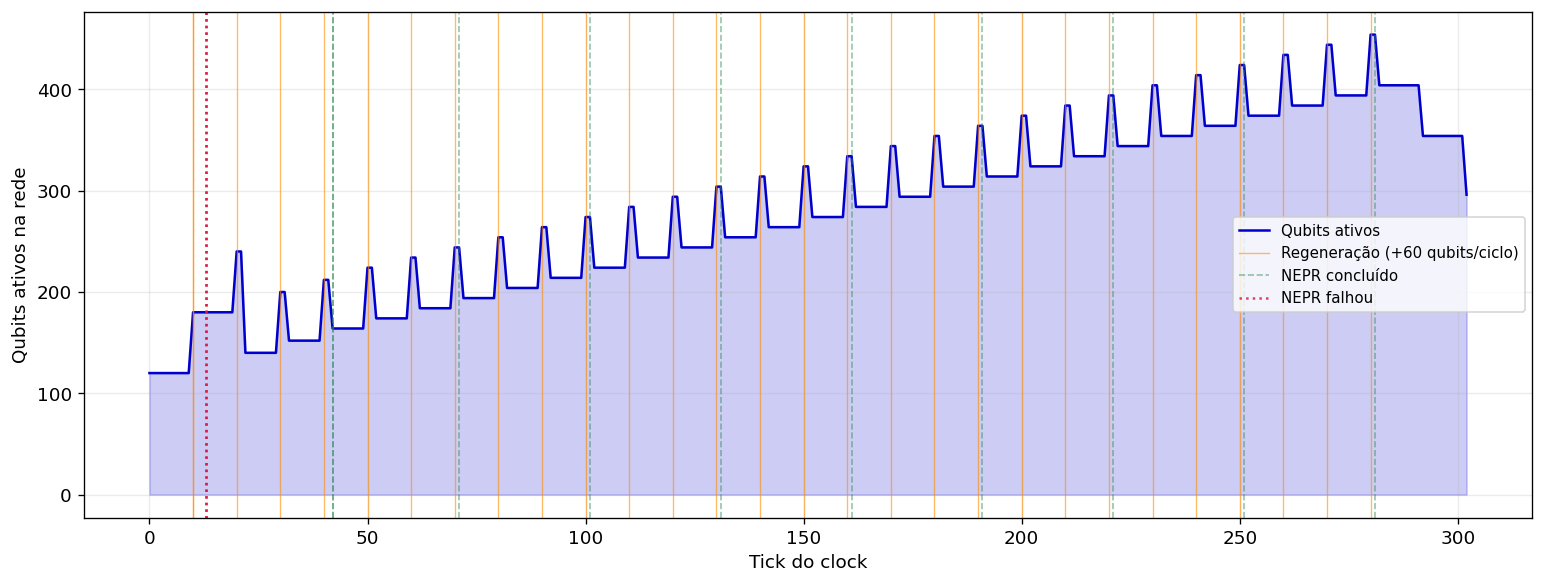

Figura salva em 'nepr_qubit_population.png'


In [13]:
# ── 11.2  Ciclo de Vida dos Qubits — População Ativa no Tempo ─────────────────
qc_per_tick = (df_v[df_v['event_type'] == 'qubit_created']['clock_tick']
               .value_counts().sort_index())
qe_per_tick = (df_v[df_v['event_type'] == 'qubit_expired']['clock_tick']
               .value_counts().sort_index())

max_t  = int(df_v['clock_tick'].max())
active = 0
pop    = []
for t in range(max_t + 1):
    active += int(qc_per_tick.get(t, 0))
    active -= int(qe_per_tick.get(t, 0))
    pop.append(active)

ticks_range = np.arange(max_t + 1)

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(ticks_range, pop, alpha=0.20, color='mediumblue')
ax.plot(ticks_range, pop, color='mediumblue', linewidth=1.5, label='Qubits ativos')

# Linhas de regeneração
for rt in regen_ticks:
    ax.axvline(rt, color='darkorange', linewidth=0.8, alpha=0.6)
ax.axvline(regen_ticks[0] if regen_ticks else -1,
           color='darkorange', linewidth=0.8, alpha=0.6,
           label=f'Regeneração (+{ROWS * COLS * config.defaults.qubit_regen_amount} qubits/ciclo)')

# Linhas de eventos NEPR
for tick in nepr_complete_ticks:
    ax.axvline(tick, color='seagreen', linestyle='--', linewidth=1, alpha=0.5)
if nepr_complete_ticks:
    ax.axvline(nepr_complete_ticks[0], color='seagreen', linestyle='--',
               linewidth=1, alpha=0.5, label='NEPR concluído')
if nepr_failed_ticks:
    for tick in nepr_failed_ticks:
        ax.axvline(tick, color='crimson', linestyle=':', linewidth=1.5, alpha=0.8)
    ax.axvline(nepr_failed_ticks[0], color='crimson', linestyle=':',
               linewidth=1.5, alpha=0.8, label='NEPR falhou')

ax.set_xlabel('Tick do clock')
ax.set_ylabel('Qubits ativos na rede')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('nepr_qubit_population.png', bbox_inches='tight')
plt.show()
print("Figura salva em 'nepr_qubit_population.png'")